<a href="https://colab.research.google.com/github/Abeerkareem/Peoject-2-LOAN-STATUS-PREDICTION/blob/main/LOAN_STATUS_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
#1. Importing Libraries

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score


In [50]:
# 2. Mounting Google Drive

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
#3. Loading the Dataset

In [53]:
Loan_df = pd.read_csv('/content/drive/My Drive/LOAN STATUS PREDICTION/loan_data.csv')

In [54]:
#4. Exploring the Dataset

In [55]:
Loan_df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [56]:
Loan_df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [57]:
Loan_df.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [58]:
Loan_df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [59]:
Loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [60]:
# 5-Drop columns that are not relevant for correlation analysis
drop_cols = ["person_gender", "person_home_ownership", "loan_intent", "person_education"]
L_df = Loan_df.drop(columns=drop_cols)

In [61]:
L_df

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,No,1
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,Yes,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,No,1
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,No,1
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,No,1
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,No,1
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,No,1
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,No,1


In [62]:
#7- Encode non-numeric columns if any remain

In [63]:

for col in L_df.select_dtypes(include="object").columns:
    L_df[col] = pd.factorize(L_df[col])[0]

In [64]:
#8- Correlation Analysis

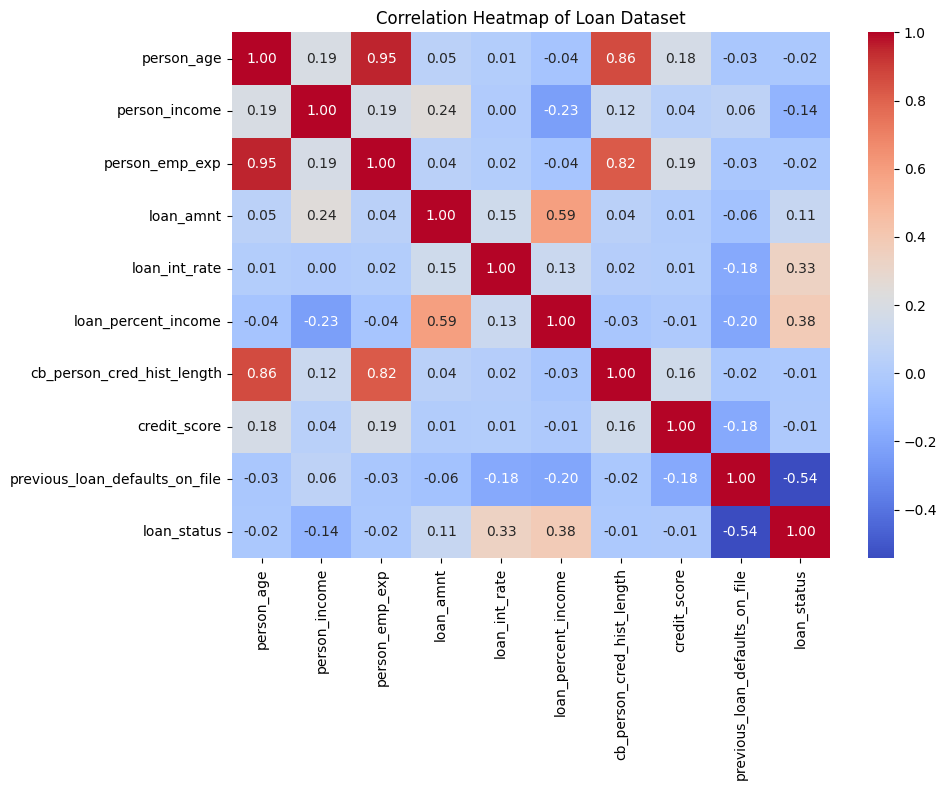

In [65]:
corr = L_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Loan Dataset")
plt.tight_layout()
plt.show()

In [66]:
#9. Data Distribution

array([[<Axes: title={'center': 'person_age'}>,
        <Axes: title={'center': 'person_income'}>,
        <Axes: title={'center': 'person_emp_exp'}>],
       [<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'loan_int_rate'}>,
        <Axes: title={'center': 'loan_percent_income'}>],
       [<Axes: title={'center': 'cb_person_cred_hist_length'}>,
        <Axes: title={'center': 'credit_score'}>,
        <Axes: title={'center': 'previous_loan_defaults_on_file'}>],
       [<Axes: title={'center': 'loan_status'}>, <Axes: >, <Axes: >]],
      dtype=object)

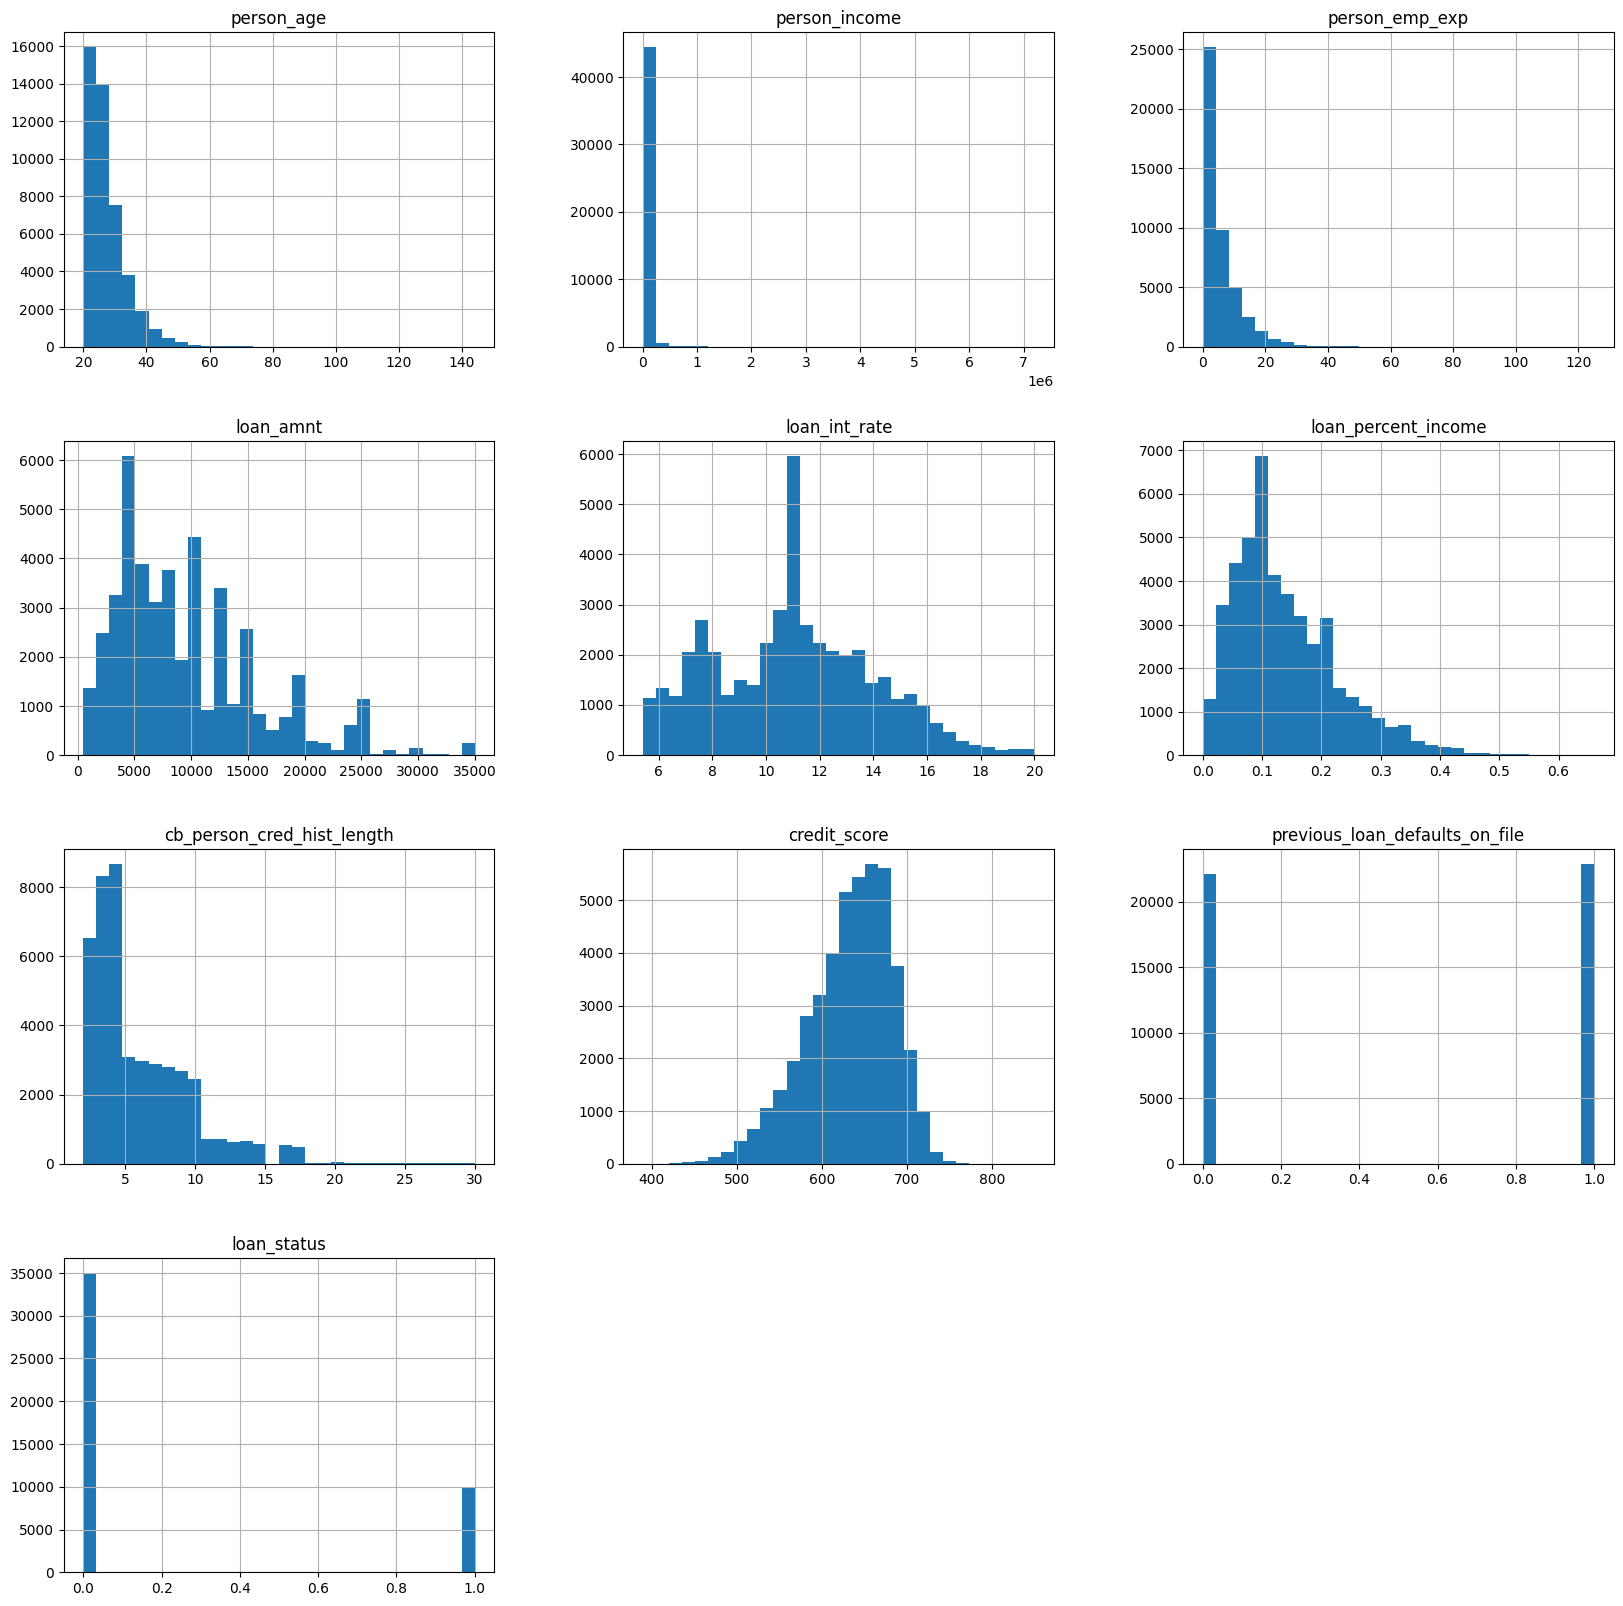

In [67]:
L_df.hist(bins=30,figsize=(20,20))

In [68]:
#10- Split features and target
X = L_df.drop("loan_status", axis=1)
y = L_df["loan_status"]

In [69]:
#11- Split train/test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
#12- Standardise numeric data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [71]:
#13-  Split Features and Target
X = L_df.drop("loan_status", axis=1)
y = L_df["loan_status"]

# 14. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#15-  Standardise Numeric Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#16-  Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=300, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

#17  Train and Evaluate Each Model
accuracy_scores = {}  # Dictionary to store accuracy scores
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = accuracy  # Store accuracy score
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy:.2f}")
    print(classification_report(y_test, y_pred, zero_division=0))

#  Notes
print("\nModels compared successfully")


=== Logistic Regression ===
Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.76      0.71      0.74      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.82      0.83      9000
weighted avg       0.88      0.89      0.88      9000


=== Random Forest ===
Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      6990
           1       0.82      0.77      0.79      2010

    accuracy                           0.91      9000
   macro avg       0.88      0.86      0.87      9000
weighted avg       0.91      0.91      0.91      9000


=== Gradient Boosting ===
Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6990
           1       0.82      0.76      0.79      2010

    accuracy                           0.91      9000
   m

In [72]:
#18-Visualising Model Accuracy

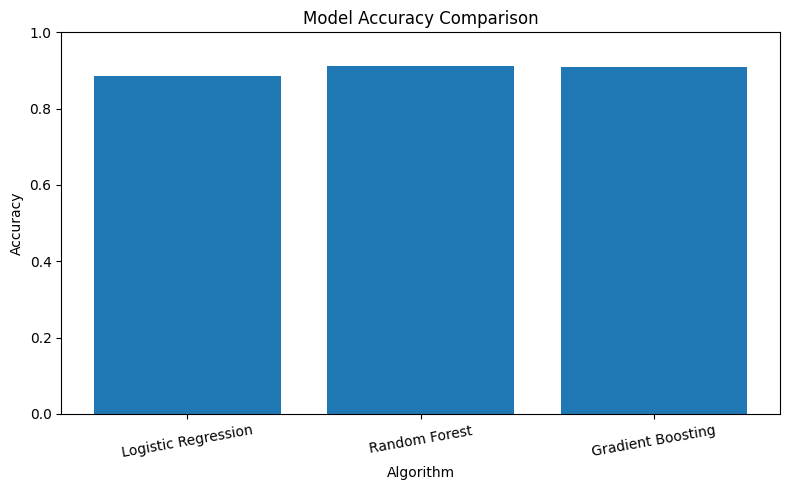

In [73]:
plt.figure(figsize=(8, 5))
plt.bar(list(accuracy_scores.keys()), list(accuracy_scores.values()))
plt.title("Model Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [74]:
#Enhance the best algorithm

In [75]:
#1-Apply Cross-Validation Instead of one random train/test split, use K-Fold Cross-Validation for more reliable performance measurement.
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Average Accuracy:", scores.mean())


Average Accuracy: 0.9113111111111112


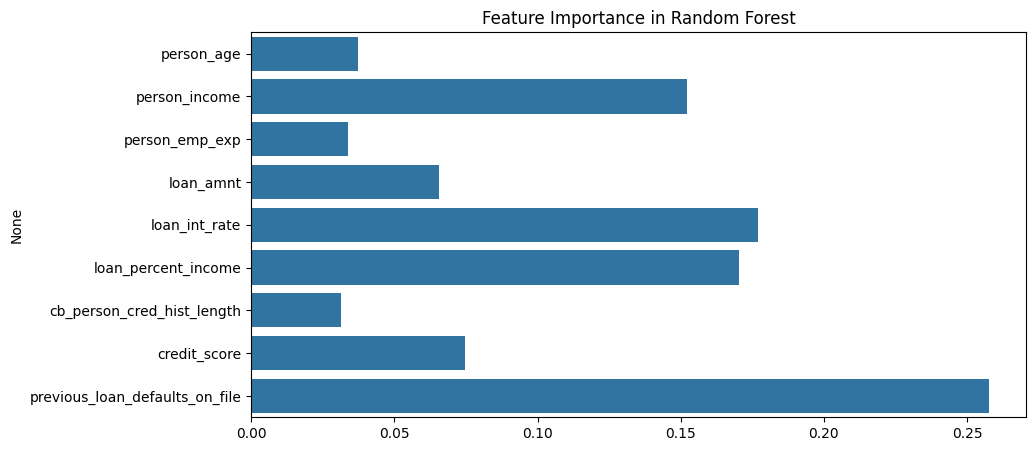

In [76]:
#2-Feature Importance & Selection , can analyse which features matter most and possibly remove weak ones.

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance in Random Forest")
plt.show()


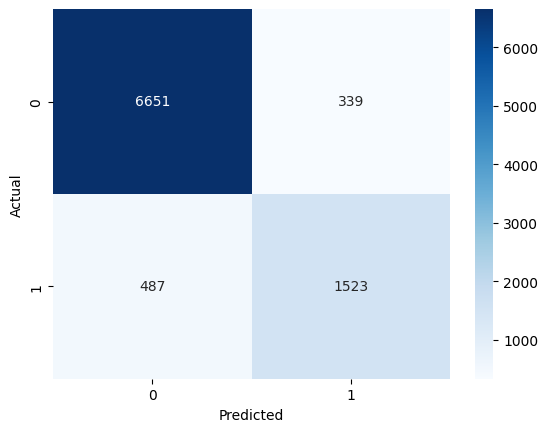

ROC AUC Score: 0.8546067943544081


In [77]:
#3-Evaluate Beyond Accuracy

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

roc_auc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc_auc)


In [78]:
#4-Try XGBoost or LightGBM

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9146666666666666
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      6990
           1       0.83      0.78      0.80      2010

    accuracy                           0.91      9000
   macro avg       0.88      0.87      0.87      9000
weighted avg       0.91      0.91      0.91      9000

